The notebook was created as a working/scratch file to explore and verify the data-analysis logic before writing it into the final Dash applications (titanic_survival_dashboard.py and titanic_survival_dashboard_advanced.py).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
filter_df = df.groupby('Sex')['Survived'].sum()
filter_df

Sex
female    233
male      109
Name: Survived, dtype: int64

Total Survivors by Sex

In [4]:
filter_df = df.groupby('Sex', as_index = False)['Survived'].sum()
filter_df

,Sex,Survived
0,female,233
1,male,109


In [5]:
df.shape

(891, 12)

Total Passenger Count by Sex

In [6]:
count = df.groupby(['Sex']).size()
count

Sex
female    314
male      577
dtype: int64

In [7]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [8]:
df['Sex'].value_counts().reset_index()

,Sex,count
0,male,577
1,female,314


Survival Rate by Class

In [9]:
survival_rate = df.groupby('Pclass')['Survived'].value_counts()
survival_rate

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

Now Rate - 

In [10]:
survival_rate = df.groupby('Pclass')['Survived'].mean().reset_index()
survival_rate

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [11]:
survival_rate['Survived'] = survival_rate['Survived'] * 100
survival_rate

,Pclass,Survived
0,1,62.962963
1,2,47.282609
2,3,24.236253


Survived by Sex

In [12]:
counts = df.groupby("Sex")["Survived"].sum().reset_index()
counts

,Sex,Survived
0,female,233
1,male,109


In [13]:
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Survival rate by class and sex

In [14]:
survival_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].value_counts().reset_index()
survival_class_sex

,Pclass,Sex,Survived,count
0,1,female,1,91
1,1,female,0,3
2,1,male,0,77
3,1,male,1,45
4,2,female,1,70
5,2,female,0,6
6,2,male,0,91
7,2,male,1,17
8,3,female,1,72
9,3,female,0,72


In [15]:
survival_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
survival_class_sex['Survived'] *= 100
survival_class_sex

,Pclass,Sex,Survived
0,1,female,96.808511
1,1,male,36.885246
2,2,female,92.105263
3,2,male,15.740741
4,3,female,50.000000
5,3,male,13.544669


<p><b>barmode = 'group'</b> is used in Plotly when you have multiple bars for the same category and want them side-by-side.</p>

<hr>

<p>Note : </p>
<p>When we need a callback?</p>

<p>we need a callback whenever something in the dashboard should update in response to user input - a dropdown, slider, button, checkbox, etc.</p>

<p>Example: if we want a dropdown to let the user pick a class (1st/2nd/3rd) and the plot updates to show only that class's data - that requires a callback, because the figure has to be recomputed when the dropdown value changes.</p>

<hr>

proportion of survived vs not survived" for a class the user selects via dropdown.

In [16]:
df['Outcome'] = df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Outcome
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Did Not Survive
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Survived
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Survived
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Survived
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Did Not Survive


In [17]:
counts = df['Outcome'].value_counts()
counts

Outcome
Did Not Survive    549
Survived           342
Name: count, dtype: int64

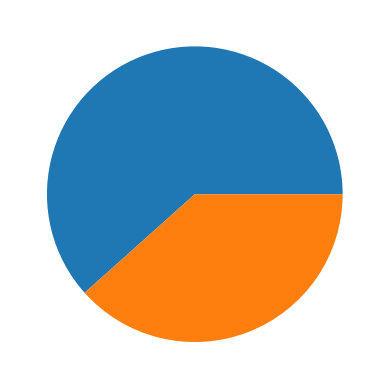

In [18]:
plt.pie(counts)
plt.show()

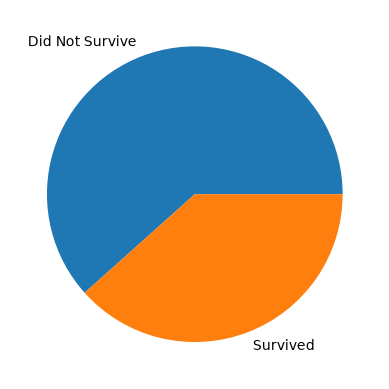

In [19]:
plt.pie(counts, labels = counts.index)
plt.show()